# 2. Unsupervised Learning — Discovering Themes With No Labels

**Scenario:** Same 300 real airline tweets as the supervised notebook — but this
time we **throw away the sentiment labels** and pretend we never had them.

The question changes from *"predict the label"* to *"find structure on its own."*
We ask the algorithm: *without being told anything, can you group these tweets
into meaningful clusters?*

This is **unsupervised learning** — there's no answer key, only the data itself.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

np.random.seed(42)

df = pd.read_csv("../data/Tweets.csv")
texts = df["text"]  # NOTE: we deliberately do not load airline_sentiment here
print(f"Loaded {len(texts)} tweets (labels intentionally ignored)")

Loaded 300 tweets (labels intentionally ignored)


## Step 1 — Turn tweets into numbers (same TF-IDF idea as before)

Same technique as the supervised notebook: convert text into numeric vectors.
The difference is what we do with them next — no labels are involved.

In [2]:
vectorizer = TfidfVectorizer(max_features=1000, stop_words="english", min_df=2)
X = vectorizer.fit_transform(texts)
print(f"Vectorized into a {X.shape[0]} x {X.shape[1]} matrix (tweets x word-features)")

Vectorized into a 300 x 354 matrix (tweets x word-features)


## Step 2 — Let K-Means find groups on its own

We ask for **4 clusters** (a reasonable guess for this dataset) — the algorithm has
no idea what "positive," "negative," "delay," or "baggage" mean. It only sees which
tweets use similar words and groups accordingly.

In [3]:
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters
df["cluster"].value_counts().sort_index()

cluster
0     50
1     22
2    100
3    128
Name: count, dtype: int64

## Step 3 — Visualize the clusters in 2D

We can't visualize 1000 word-dimensions directly, so we compress each tweet down
to 2 dimensions (PCA) just for plotting. Tweets that ended up in the same cluster
should visually group together.

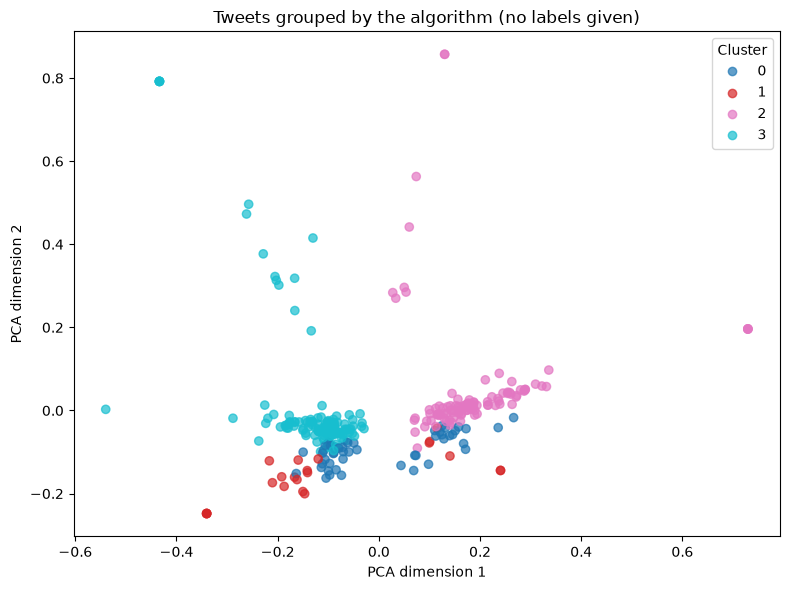

In [4]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap="tab10", alpha=0.7)
plt.title("Tweets grouped by the algorithm (no labels given)")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.tight_layout()
plt.show()

## Step 4 — What is each cluster actually about?

The algorithm found groups, but it can't name them — that part is still human
judgment. We look at the top distinctive words per cluster to interpret what
theme each one represents (e.g., "delay," "baggage," "thank," "seat").

In [5]:
feature_names = np.array(vectorizer.get_feature_names_out())
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(N_CLUSTERS):
    top_words = feature_names[order_centroids[i, :10]]
    print(f"Cluster {i} ({(df['cluster'] == i).sum()} tweets) — top words: {', '.join(top_words)}")

Cluster 0 (50 tweets) — top words: flight, united, virginamerica, cancelled, delayed, just, flightled, gate, wait, change
Cluster 1 (22 tweets) — top words: thanks, united, virginamerica, ll, bag, changed, fun, got, info, wait
Cluster 2 (100 tweets) — top words: virginamerica, http, thank, virgin, way, guys, just, love, austin, flying
Cluster 3 (128 tweets) — top words: united, thank, dm, http, like, great, customer, child, response, gate


## Step 5 — A few example tweets from each cluster

Reading a handful of actual tweets per cluster makes the theme concrete for the
class — much more intuitive than a list of keywords alone.

In [6]:
for i in range(N_CLUSTERS):
    print(f"\\n--- Cluster {i} sample tweets ---")
    sample = df[df["cluster"] == i]["text"].sample(min(3, (df["cluster"] == i).sum()), random_state=1)
    for t in sample:
        print(f"  • {t}")

\n--- Cluster 0 sample tweets ---
  • @VirginAmerica love the 90s music blasting at gate in #Boston while waiting for flight to #SanFrancisco. Only if I could get an iced coffee!
  • @united they're not, actually. gate agent was so rude. now standing in a line waiting for reFlight Booking Problems. missed the only flight to STI. awful.
  • @virginamerica Digging the swanky pink mood lighting during the flight from NYC to SFO.  Just needs a cabaret singer.  Think about it!
\n--- Cluster 1 sample tweets ---
  • @united thanks. Just a program comment; the system assigned seats behind each other even though pairs were available. I changed it back.
  • @united thanks United I understand that. But he would actually like his own bag back! What have you done with it?! He also wants the money..
  • @united But thanks for asking
\n--- Cluster 2 sample tweets ---
  • @VirginAmerica has getaway deals through May, from $59 one-way. Lots of cool cities http://t.co/QDlJHslOI5 #CheapFlights #FareCompa

## Talking points for the class

1. **No answer key this time.** The algorithm was never told what "delay" or
   "compliment" means — it only measured which tweets use similar words.
2. **The number of clusters is a human choice.** We picked 4; try changing
   `N_CLUSTERS` to 3 or 6 and re-run to show the class how the groupings shift.
3. **Naming the clusters is still a human job.** The algorithm hands you groups;
   a person still has to look at the top words and sample tweets and decide
   "this cluster is about baggage complaints."
4. **Real-world use:** this is exactly how a brand-monitoring dashboard
   auto-groups thousands of mentions into themes (delays, pricing, service,
   praise) *before* anyone reads a single one manually.
5. **Contrast with the supervised notebook:** same data, same TF-IDF numeric
   representation — but a completely different task (predict a known label
   vs. discover unknown structure).